
Bên dưới là phần vẽ hàm tuyến tính sau khi nhận thấy fit với hàm bậc nhất sau khi thử các hàm bậc 2,3,4 trong fit_function.

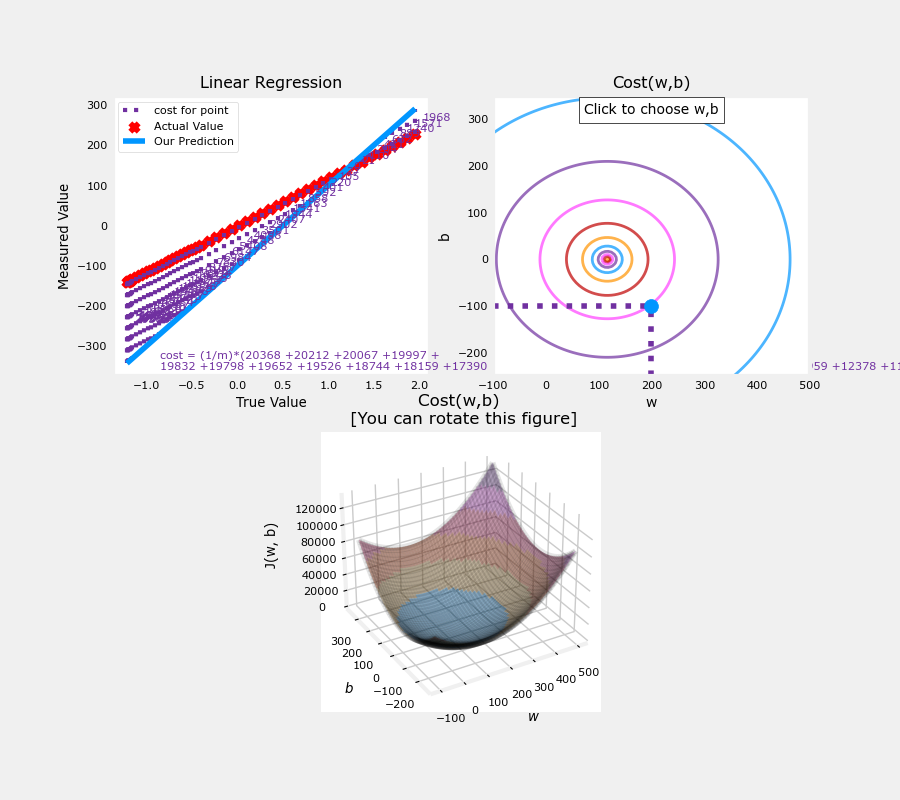

In [2]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
x_train = np.array([
    3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50,
                    55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 110, 120, 130, 
                    140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 
                    250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 
                    360, 370, 380
])

y_train = np.array([
    2.962, 3.8648, 4.8237, 6.1511, 7.005, 8.515, 9.4552, 10.4988,
                    14.9004, 20.2482, 24.5709, 29.7015, 33.941, 38.9905, 43.6784, 48.0311,
                    52.7, 57.8442, 62.5892, 67.4436, 72.0883, 76.8276, 81.8644, 86.3656,
                    91.2202, 96.3647, 105.961, 115.7981, 125.2903, 135.1993, 145.44, 155.3276,
                    165.2622, 174.5583, 184.5487, 194.3147, 204.2765, 213.7839, 223.7707,
                    233.5522, 244.2693, 253.7179, 264.0291, 273.6122, 282.6807, 293.3765,
                    301.8912, 313.2924, 321.2665, 331.5217, 341.7111, 350.8723, 361.4075, 371.5148
])
mx, sx = x_train.mean(), x_train.std()
my     = y_train.mean()
x_s    = (x_train - mx)/sx
y_s    = (y_train - my)
# dùng x_s, y_s cho các hàm vẽ

from render_figure import plt_intuition, plt_stationary, plt_update_onclick, soup_bowl, plt_gradients
plt.style.use('./deeplearning.mplstyle')
plt.close('all') 
fig, ax, dyn_items = plt_stationary(x_s, y_s)
updater = plt_update_onclick(fig, ax, x_s, y_s, dyn_items)

In [3]:
def compute_cost(x, y, w, b): 
    """
    Computes the cost function for linear regression.
    
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    # number of training examples
    m = x.shape[0] 
    
    cost_sum = 0 
    for i in range(m): 
        f_wb = w * x[i] + b   
        cost = (f_wb - y[i]) ** 2  
        cost_sum = cost_sum + cost  
    total_cost = (1 / (2 * m)) * cost_sum  

    return total_cost

In [4]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
from render_figure import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

In [5]:
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_db_i = f_wb - y[i] 
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

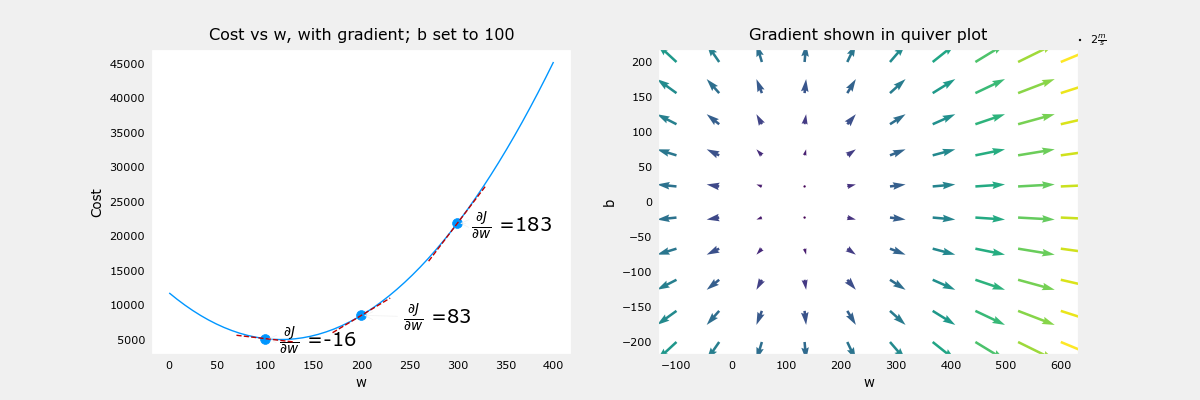

In [6]:
plt_gradients(x_s,y_s, compute_cost, compute_gradient)
plt.show()

In [7]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    
    w = copy.deepcopy(w_in) # avoid modifying global w_in
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 
    return w, b, J_history, p_history #return w and J,w history for graphing

In [8]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_s ,y_s, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")
def convert_to_original_params(w_s, b_s, mx, sx, my):
    w = w_s / sx
    b = my + b_s - w * mx
    return w, b
w, b = convert_to_original_params(w_final, b_final, mx, sx, my)
print(w, b) 

Iteration    0: Cost 6.62e+03  dj_dw: -1.163e+02, dj_db: -4.211e-15   w:  1.163e+00, b: 4.21062e-17
Iteration 1000: Cost 2.48e-01  dj_dw: -5.019e-03, dj_db:  1.678e-15   w:  1.163e+02, b:-7.11102e-15
Iteration 2000: Cost 2.48e-01  dj_dw: -2.167e-07, dj_db:  1.612e-15   w:  1.163e+02, b:-7.09260e-15
Iteration 3000: Cost 2.48e-01  dj_dw: -9.351e-12, dj_db: -2.895e-15   w:  1.163e+02, b:-7.08536e-15
Iteration 4000: Cost 2.48e-01  dj_dw: -6.966e-13, dj_db: -3.290e-15   w:  1.163e+02, b:-7.08536e-15
Iteration 5000: Cost 2.48e-01  dj_dw: -6.981e-13, dj_db:  1.711e-15   w:  1.163e+02, b:-7.09062e-15
Iteration 6000: Cost 2.48e-01  dj_dw: -6.981e-13, dj_db:  1.711e-15   w:  1.163e+02, b:-7.09589e-15
Iteration 7000: Cost 2.48e-01  dj_dw: -6.981e-13, dj_db:  1.711e-15   w:  1.163e+02, b:-7.10115e-15
Iteration 8000: Cost 2.48e-01  dj_dw: -6.981e-13, dj_db:  1.711e-15   w:  1.163e+02, b:-7.10641e-15
Iteration 9000: Cost 2.48e-01  dj_dw: -6.981e-13, dj_db:  1.711e-15   w:  1.163e+02, b:-7.11168e-15


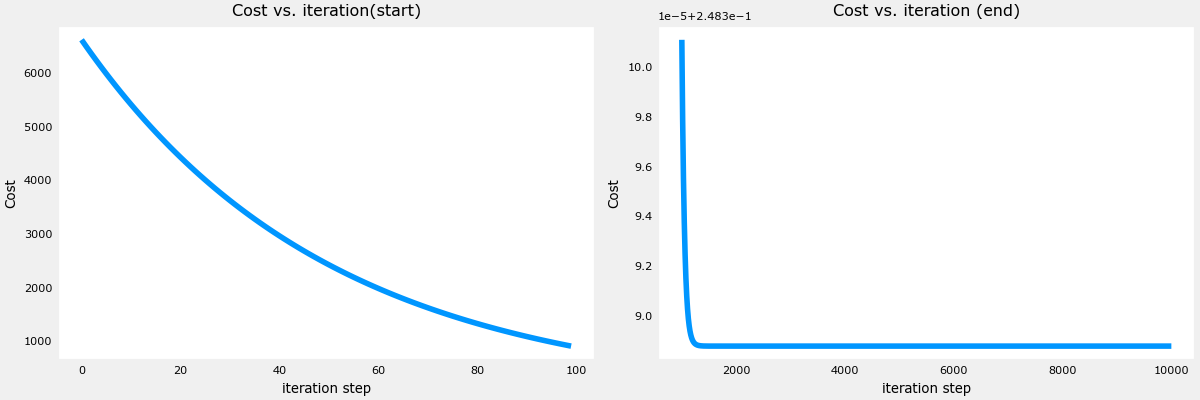

In [9]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

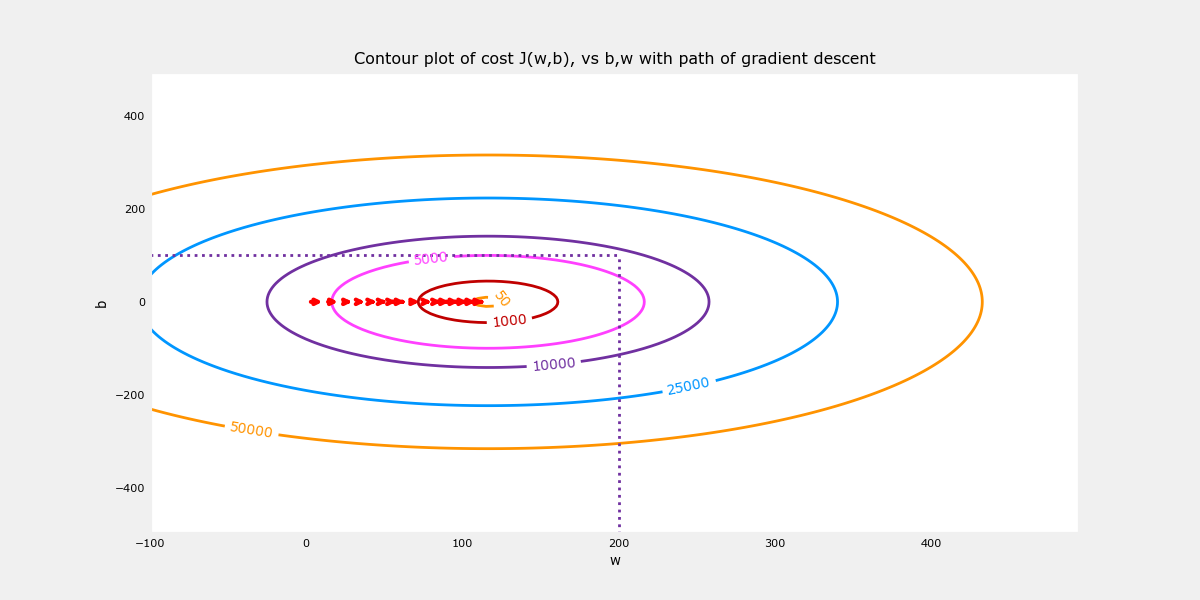

In [10]:
fig, ax = plt.subplots(1,1, figsize=(12, 6))
plt_contour_wgrad(x_s, y_s, p_hist, ax)

In [11]:
# initialize parameters
w_init = 0
b_init = 0
# set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: Cost 1.40e+13  dj_dw: -3.493e+04, dj_db: -1.432e+02   w:  2.794e+04, b: 1.14591e+02
Iteration    1: Cost 1.15e+22  dj_dw:  1.001e+09, dj_db:  4.112e+06   w: -8.011e+08, b:-3.28946e+06
Iteration    2: Cost 9.45e+30  dj_dw: -2.871e+13, dj_db: -1.179e+11   w:  2.297e+13, b: 9.43158e+10
Iteration    3: Cost 7.77e+39  dj_dw:  8.233e+17, dj_db:  3.380e+15   w: -6.586e+17, b:-2.70424e+15
Iteration    4: Cost 6.39e+48  dj_dw: -2.360e+22, dj_db: -9.692e+19   w:  1.888e+22, b: 7.75363e+19
Iteration    5: Cost 5.25e+57  dj_dw:  6.768e+26, dj_db:  2.779e+24   w: -5.414e+26, b:-2.22313e+24
Iteration    6: Cost 4.32e+66  dj_dw: -1.941e+31, dj_db: -7.968e+28   w:  1.552e+31, b: 6.37420e+28
Iteration    7: Cost 3.55e+75  dj_dw:  5.564e+35, dj_db:  2.285e+33   w: -4.451e+35, b:-1.82762e+33
Iteration    8: Cost 2.92e+84  dj_dw: -1.595e+40, dj_db: -6.550e+37   w:  1.276e+40, b: 5.24018e+37
Iteration    9: Cost 2.40e+93  dj_dw:  4.574e+44, dj_db:  1.878e+42   w: -3.659e+44, b:-1.50247e+42


y = 0.97628x + -0.43694


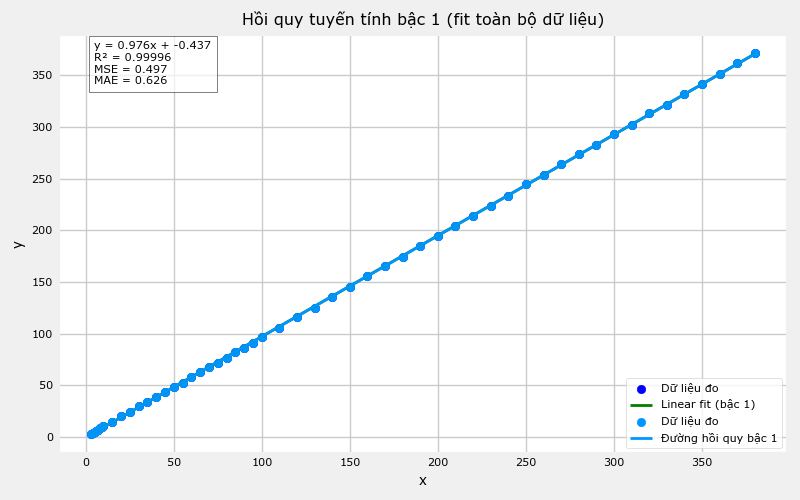

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
x_array=x_train;
y_array=y_train
X = x_array.reshape(-1, 1)
y = y_array

model = LinearRegression()
model.fit(X, y)

a = model.coef_[0]
b = model.intercept_
print(f"y = {a:.5f}x + {b:.5f}")

# vẽ
x_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_line = model.predict(x_line)

plt.scatter(x_array, y_array, label="Dữ liệu đo")
plt.plot(x_line, y_line, label="Đường hồi quy bậc 1", linewidth=2)
plt.legend()
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.show()
